In [2]:
#  ********************************************* MODEL TRAINING **************************************************
# TODO: Create train_models function orchestrating both training pipelines
# TODO: Add progress reporting during training
# TODO: Handle missing model data with informative errors

# TODO: Import pandas, numpy for data handling
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
# TODO: Import scikit-learn models (RandomForestClassifier)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
# TODO: Import LabelEncoder and train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
# TODO: Import pickle for model persistence
import pickle 
import os
import logging
import joblib 

In [1]:
logging.basicConfig(level=logging.INFO)
logger= logging.getLogger(__name__)

NameError: name 'logging' is not defined

INFO:__main__:Loading risk profile training data
INFO:__main__:Training RandomForest Model for risk assessment...
INFO:__main__:Risk Model Train Accuracy: 0.90
INFO:__main__:Risk Model Test Accuracy: 0.81
INFO:__main__:Risk Model Test Accuracy (Gradient Boosting): 0.82
INFO:__main__:
 Classification Report (Gradient Boosting): 

              precision    recall  f1-score   support

        High       0.85      0.81      0.83      2716
         Low       0.89      0.85      0.87      2809
    Moderate       0.75      0.81      0.78      3475

    accuracy                           0.82      9000
   macro avg       0.83      0.82      0.83      9000
weighted avg       0.83      0.82      0.82      9000

INFO:__main__:Risk model saved successfully.
INFO:__main__:Risk Profile => Encoders saved successfully


[(0.3096954016737333, 'age'), (0.2593475669755821, 'investment_horizon_years'), (0.14716042332278673, 'annual_income'), (0.13188269074391812, 'investment_experience_level'), (0.10046184036090862, 'current_savings'), (0.05145207692307125, 'number_of_dependents')]


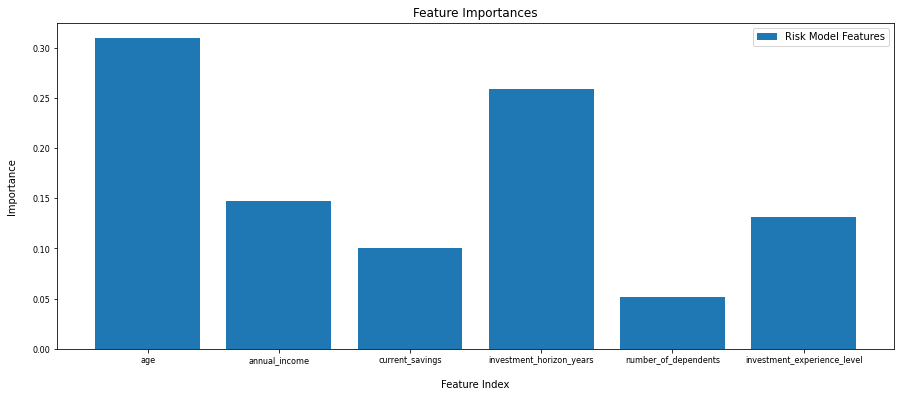

In [21]:
# TODO: Create train_risk_model function:
#   - Load training data from CSV
#   - Prepare features and target variable
#   - Split data into train/test sets
#   - Train RandomForest classifier
#   - Evaluate model performance
#   - Save model and encoders to disk

def train_risk_model():
    try: 
        logger.info("Loading risk profile training data")
        risk_df=pd.read_csv("data/risk_profile_training_dataset.csv") 
        if risk_df.empty:
            raise ValueError("Risk profile dataset is empty!")
        
        target_col="risk_profile"

        label_encoder = LabelEncoder()
        risk_df["investment_experience_level"]=label_encoder.fit_transform(risk_df["investment_experience_level"])
        feature_cols=["age","annual_income","current_savings","investment_horizon_years","number_of_dependents","investment_experience_level"]
        
        X=risk_df[feature_cols]
        y=risk_df[target_col]

        y_label_encoder = LabelEncoder()
        y_encoded = y_label_encoder.fit_transform(y)

        X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.3, random_state=42)

        #===================================================================================== Hyperparameter Tuning
        #=========================================================================================== Tuning Done 

        logger.info('Training RandomForest Model for risk assessment...')
        model = RandomForestClassifier(n_estimators= 300, random_state=42,class_weight="balanced",criterion='entropy',
                                        max_depth=15, min_samples_split=5,min_samples_leaf=4, max_features='sqrt',bootstrap=True,max_samples=0.8)
        model.fit(X_train,y_train)

        y_pred_1 = model.predict(X_train)
        acc1 = accuracy_score(y_train, y_pred_1)
        logger.info (f"Risk Model Train Accuracy: {acc1:.2f}")

        y_pred = model.predict(X_test)
        acc= accuracy_score(y_test, y_pred)
        logger.info (f"Risk Model Test Accuracy: {acc:.2f}")
        # logger.info("\n"+ classification_report(y_test,y_pred,target_names=y_label_encoder.classes_))

        # Training a Gradient Boosting Classifier
        gb_model = GradientBoostingClassifier(random_state=1, n_estimators=500, learning_rate=0.1)
        gb_model.fit(X_train, y_train)

        # Making predictions
        y_pred_gb = gb_model.predict(X_test)
        # Evaluating the model
        accuracy_gb = accuracy_score(y_test, y_pred_gb)
        logger.info (f"Risk Model Test Accuracy (Gradient Boosting): {accuracy_gb:.2f}")
        logger.info("\n Classification Report (Gradient Boosting): \n\n" + classification_report(y_test,y_pred_gb,target_names=y_label_encoder.classes_))


#         # Generate learning curve data
#         train_sizes, train_scores, test_scores = learning_curve(
#             model, X_train, y_train, cv=5, n_jobs=-1,
#             train_sizes=np.linspace(0.1, 1.0, 50),  # Vary training set size from 10% to 100%
#             scoring='accuracy'
#         )

#         # Calculate mean and standard deviation for scores
#         train_scores_mean = np.mean(train_scores, axis=1)
#         train_scores_std = np.std(train_scores, axis=1)
#         test_scores_mean = np.mean(test_scores, axis=1)
#         test_scores_std = np.std(test_scores, axis=1)

#         # Plot the learning curve
#         plt.figure(figsize=(10, 6))
#         plt.title("Random Forest Training Curve")
#         plt.xlabel("Training Examples -->", labelpad= 15)
#         plt.ylabel("Accuracy Score (train and validation) -->", labelpad= 15)
#         plt.xlim(0,20000)
#         plt.ylim(0,1.2)
#         # plt.grid()

#         plt.plot(train_sizes, train_scores_mean,'o-',color="r",label="Training Accuracy")
#         plt.plot(train_sizes, test_scores_mean,'o-',color="g",label="Validation Accuracy")
#         plt.legend(loc="upper right")
#         plt.show()

        # saving the model and encoders
        logger.info("Risk model saved successfully.")
        logger.info("Risk Profile => Encoders saved successfully")

        # Plot feature importances
        feature_importances = model.feature_importances_
#         indices = np.argsort(feature_importances)[::-1]

        print(sorted(zip(model.feature_importances_, X.columns), reverse=True))

        plt.figure(figsize=(15, 6))
        plt.bar(range(X.shape[1]), feature_importances, label = "Risk Model Features")
        plt.xticks(range(X.shape[1]), feature_cols, rotation=0, fontsize=8)
        plt.yticks(fontsize=8)
        plt.legend(loc="upper right")
        plt.title('Feature Importances')
        plt.xlabel('Feature Index', labelpad= 15)
        plt.ylabel('Importance', labelpad= 15)
        plt.show()

    except FileNotFoundError:
        logger.error("Risk profile training data not found.")
    except Exception as e:
        logger.error(f"Error Training risk model: {e}")
    

train_risk_model()

INFO:__main__:Loading goal success training data...
INFO:__main__:Goal Success Model Train Accuracy: 0.94
INFO:__main__:Goal Success Model Test Accuracy: 0.86
INFO:__main__:Goal Success Model Test Accuracy (Gradient Boosting): 0.89
INFO:__main__:
 Classification Report (Gradient Boosting): 

              precision    recall  f1-score   support

      Likely       0.86      0.86      0.86      2130
    Moderate       0.71      0.67      0.69      1662
    Unlikely       0.95      0.97      0.96      5208

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000

INFO:__main__:Goal Success model saved successfully.
INFO:__main__:Goal Success => Target Encoder saved successfully


[(0.38181743665000806, 'investment_horizon_years'), (0.1891267576721916, 'target_goal_amount'), (0.1332575262537553, 'age'), (0.1263402054571061, 'annual_income'), (0.11109062343359537, 'current_savings'), (0.03192380828806812, 'investment_experience_level'), (0.02644364224527542, 'number_of_dependents')]


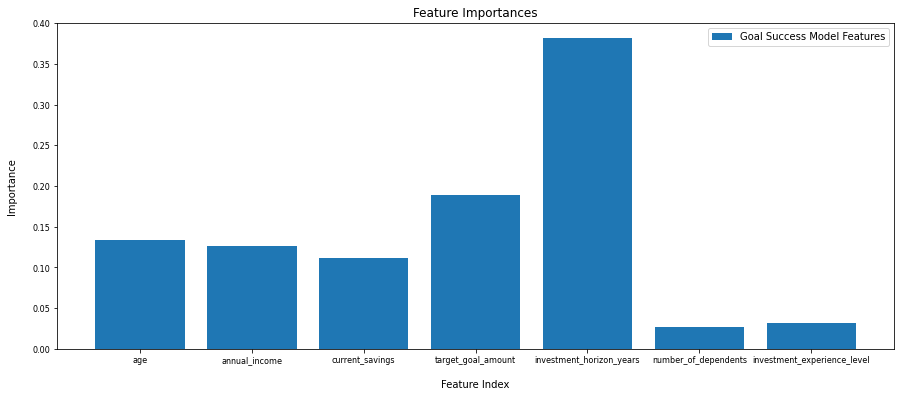

In [20]:
# TODO: Create train_goal_model function:
#   - Load training data
#   - Prepare features for goal success prediction
#   - Train classifier
#   - Evaluate performance
#   - Save model and encoders

def train_goal_model():
    try:
        logger.info("Loading goal success training data...")
        goal_df=pd.read_csv("data/goal_success_training_dataset.csv")
        if goal_df.empty:
            raise ValueError("Goal success dataset is empty!")

        target_col="goal_success"
        
        label_encoder = LabelEncoder()
        goal_df["investment_experience_level"]=label_encoder.fit_transform(goal_df["investment_experience_level"])
        feature_cols=["age","annual_income","current_savings","target_goal_amount","investment_horizon_years","number_of_dependents","investment_experience_level"]
        
        X=goal_df[feature_cols]
        y=goal_df[target_col]

        y_label_encoder = LabelEncoder()
        y_encoded = y_label_encoder.fit_transform(y)

        X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.3, random_state=42)

        model = RandomForestClassifier(n_estimators= 300, random_state=42,class_weight="balanced",criterion='entropy',
                                       max_depth=15, min_samples_split=5,min_samples_leaf=4, max_features='sqrt',
                                       bootstrap=True,max_samples=0.8)
        model.fit(X_train,y_train)

        y_pred_1 = model.predict(X_train)
        acc1 = accuracy_score(y_train, y_pred_1)
        logger.info (f"Goal Success Model Train Accuracy: {acc1:.2f}")

        y_pred = model.predict(X_test)
        acc= accuracy_score(y_test, y_pred)
        logger.info (f"Goal Success Model Test Accuracy: {acc:.2f}")
        # logger.info("\n"+ classification_report(y_test,y_pred,target_names=y_label_encoder.classes_))

        # Training a Gradient Boosting Classifier
        gb_model = GradientBoostingClassifier(random_state=1, n_estimators=500, learning_rate=0.1)
        gb_model.fit(X_train, y_train)

        # Making predictions
        y_pred_gb = gb_model.predict(X_test)
        # Evaluating the model
        accuracy_gb = accuracy_score(y_test, y_pred_gb)
        logger.info (f"Goal Success Model Test Accuracy (Gradient Boosting): {accuracy_gb:.2f}")
        logger.info("\n Classification Report (Gradient Boosting): \n\n" + classification_report(y_test,y_pred_gb,target_names=y_label_encoder.classes_))

#         # Generate learning curve data
#         train_sizes, train_scores, test_scores = learning_curve(
#             model, X_train, y_train, cv=5, n_jobs=-1,
#             train_sizes=np.linspace(0.1, 1.0, 100),  # Vary training set size from 10% to 100%
#             scoring='accuracy'
#         )

#         # Calculate mean and standard deviation for scores
#         train_scores_mean = np.mean(train_scores, axis=1)
#         train_scores_std = np.std(train_scores, axis=1)
#         test_scores_mean = np.mean(test_scores, axis=1)
#         test_scores_std = np.std(test_scores, axis=1)

#         # Plot the learning curve
#         plt.figure(figsize=(10, 6))
#         plt.title("Random Forest Training Curve")
#         plt.xlabel("Training Examples -->", labelpad= 15)
#         plt.ylabel("Accuracy Score (train and validation) -->", labelpad= 15)
#         plt.xlim(0,20000)
#         plt.ylim(0,1.2)
#         # plt.grid()

#         plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
#                         train_scores_mean + train_scores_std, alpha=0.1,
#                         color="r")
#         plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
#                         test_scores_mean + test_scores_std, alpha=0.1,
#                         color="g")
#         plt.plot(train_sizes, train_scores_mean,'+-',color="r",label="Training Accuracy")
#         plt.plot(train_sizes, test_scores_mean,'*-',color="g",label="Validation Accuracy")
#         plt.legend(loc="upper right")
#         plt.show()

        # saving the model and encoders
        logger.info("Goal Success model saved successfully.")
        logger.info("Goal Success => Target Encoder saved successfully")
        
        
        # Plot feature importances
        feature_importances = model.feature_importances_
#         indices = np.argsort(feature_importances)[::-1]

#         print(zip(X.columns, model.feature_importances_))
        print(sorted(zip(model.feature_importances_, X.columns), reverse=True))

        
        plt.figure(figsize=(15, 6))
        plt.bar(range(X.shape[1]), feature_importances, label ="Goal Success Model Features")
        plt.xticks(range(X.shape[1]), feature_cols, rotation=0, fontsize=8)
        plt.legend(loc="upper right")
        plt.yticks(fontsize=8)
        plt.title('Feature Importances')
        plt.xlabel('Feature Index', labelpad= 15)
        plt.ylabel('Importance', labelpad= 15)
        plt.show()

    except FileNotFoundError:
        logger.error("Goal success training data not found.")
    except Exception as e:
        logger.error(f"Error Training goal success model: {e}")



train_goal_model()

In [1]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing the train dataset
risk_df=pd.read_csv("data/risk_profile_training_dataset.csv") 
risk_df

,age,annual_income,current_savings,investment_horizon_years,number_of_dependents,investment_experience_level,risk_profile
0,56,419417,857876,7,0,Intermediate,Moderate
1,69,1354760,2064122,-4,0,Beginner,Low
2,46,459535,616684,18,2,Intermediate,Moderate
3,32,4064302,5779517,3,0,Intermediate,High
4,60,1312027,1920112,5,0,Advanced,Moderate
...,...,...,...,...,...,...,...
29995,61,371930,1173658,4,0,Beginner,Low
29996,57,284547,610571,8,1,Beginner,Low
29997,57,3423538,3828389,8,0,Intermediate,Moderate
29998,47,4512807,4361793,7,1,Intermediate,Moderate


In [3]:
# Checking if there is any null value in any column of the train dataset
risk_df.isnull().sum()

age                            0
annual_income                  0
current_savings                0
investment_horizon_years       0
number_of_dependents           0
investment_experience_level    0
risk_profile                   0
dtype: int64

In [4]:
#  Non-Null count and data type info for each column of the train dataset
risk_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   age                          30000 non-null  int64 
 1   annual_income                30000 non-null  int64 
 2   current_savings              30000 non-null  int64 
 3   investment_horizon_years     30000 non-null  int64 
 4   number_of_dependents         30000 non-null  int64 
 5   investment_experience_level  30000 non-null  object
 6   risk_profile                 30000 non-null  object
dtypes: int64(5), object(2)
memory usage: 1.6+ MB


In [5]:
# Heatmap of the train dataset
# f, ax = plt.subplots(figsize=(10, 8))
# corr = risk_df.corr()
# sns.heatmap(corr,mask=np.zeros_like(corr, dtype=bool),cmap=sns.diverging_palette(220, 10, as_cmap=True),square=True,ax=ax,annot=True)
# sns.set_context('paper', font_scale = 2)
# plt.show()

In [6]:
ds2=pd.DataFrame()
ds2['risk_profile']=risk_df.risk_profile
# ds2

In [7]:
# Making target column to numeric "acc, good, vgood = 1" and "unacc = 0"
ds2.risk_profile = ds2["risk_profile"].astype(str).replace('Low', 0)
ds2.risk_profile = ds2["risk_profile"].astype(str).replace('Moderate', 1)
ds2.risk_profile = ds2["risk_profile"].astype(str).replace('High', 2)

# ds2
res=ds2.astype(int)
res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   risk_profile  30000 non-null  int32
dtypes: int32(1)
memory usage: 117.3 KB


In [219]:
ds3=res.sort_values(by='risk_profile')
# ds3

In [224]:
ds=pd.DataFrame()
ds['Risk Profile']=risk_df.risk_profile
# ds

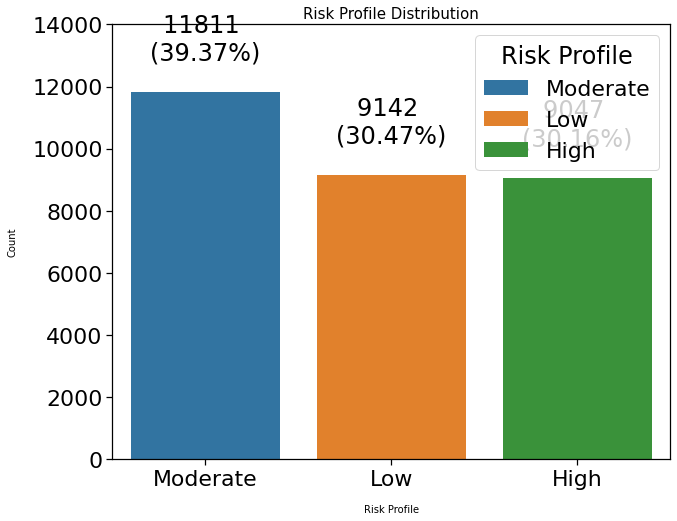

In [233]:
# Target
plt.figure(figsize=(10,8))

ax=sns.countplot(x=risk_df["risk_profile"], hue =ds['Risk Profile'] , dodge=False, 
              order=risk_df['risk_profile'].value_counts(ascending=False).index)
n='\n'
abs_values = risk_df['risk_profile'].value_counts(ascending=False)
rel_values = risk_df['risk_profile'].value_counts(ascending=False, normalize=True).values * 100
lbls = [f'{p[0]} \n({round(p[1],2)}%)\n' for p in zip(abs_values, rel_values)]

ax.bar_label(container=ax.containers[0], labels=lbls)
ax.bar_label(container=ax.containers[1], labels=lbls)
ax.bar_label(container=ax.containers[2], labels=lbls)

# plt.legend(labels=['Low', 'Moderate', 'High'], loc="upper right")
plt.title('Risk Profile Distribution', fontsize=15)
plt.xlabel('Risk Profile', fontsize=10, labelpad= 15)
plt.ylabel('Count', fontsize=10, labelpad= 15)
plt.ylim(0,14000)
plt.show()

In [12]:
abs_values

risk_profile
Moderate    11811
Low          9142
High         9047
Name: count, dtype: int64

In [13]:
rel_values

array([39.37      , 30.47333333, 30.15666667])

In [64]:
lbls

['11811 \n(39.37%)', '9142 \n(30.47%)', '9047 \n(30.16%)']

In [118]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Decision Tree Classifier (using criterion : Gini )
train_acc1=[]
val_acc1=[]
test_acc1=[]
max_depth=[]
# Calculating the test error
MSE_Train=[]
MSE_Test=[]

for i in range(1,16):
    
    risk_df=pd.read_csv("data/risk_profile_training_dataset.csv") 

    target_col="risk_profile"

    label_encoder = LabelEncoder()
    risk_df["investment_experience_level"]=label_encoder.fit_transform(risk_df["investment_experience_level"])
    feature_cols=["age","annual_income","current_savings","investment_horizon_years","number_of_dependents","investment_experience_level"]

    X=risk_df[feature_cols]
    y=risk_df[target_col]

    y_label_encoder = LabelEncoder()
    y_encoded = y_label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.3, random_state=42)
        

    # ******************************************    
        
    max_depth.append(i)
    
    # Random Forest Classifier
    random_forest_1 = RandomForestClassifier(criterion='entropy', random_state=42, n_jobs=-1, max_depth=i, n_estimators=300, oob_score=True)
    
    
    # Train the model on the training data
    random_forest_1.fit(X_train,y_train)
#     y_pred_1 = model.predict(X_train)
    
    # Make predictions on the given data
    y_pred_train = random_forest_1.predict(X_train)
    y_pred_test = random_forest_1.predict(X_test)
    
    train_acc1.append(round(random_forest_1.score(X_train, y_train),2))
    val_acc1.append(round(random_forest_1.score(X_test, y_test),2))

    # Evaluating accuracy, precision, recall and f1-score
    accuracy_decision_tree = accuracy_score(y_test, y_pred_test)
    precision_decision_tree = precision_score(y_test, y_pred_test, average='weighted')
    recall_decision_tree = recall_score(y_test, y_pred_test, average='weighted')
    f1_decision_tree = f1_score(y_test, y_pred_test, average='weighted')
    
    test_acc1.append(round(accuracy_decision_tree,2))
    
    # Calculating mean square error
    mse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    mse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    MSE_Train.append(mse_train)
    MSE_Test.append(mse_test)

    print ('Max_Depth:', i)
    print(f'Decision Tree Accuracy: {accuracy_decision_tree:.2f}')
    print(f'Decision Tree Precision: {precision_decision_tree:.2f}')
    print(f'Decision Tree Recall: {recall_decision_tree:.2f}')
    print(f'Decision Tree F1 Score: {f1_decision_tree:.2f}')
    print('--------------------------------------------------------')
    print ('Mean Squared Error (TRAIN):', mse_train)
    print ('Mean Squared Error (TEST):', mse_test)
    print('\n')

    


C:\Users\USER\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Max_Depth: 1
Decision Tree Accuracy: 0.56
Decision Tree Precision: 0.45
Decision Tree Recall: 0.56
Decision Tree F1 Score: 0.48
--------------------------------------------------------
Mean Squared Error (TRAIN): 1.1563695240667995
Mean Squared Error (TEST): 1.1574397032531183


Max_Depth: 2
Decision Tree Accuracy: 0.68
Decision Tree Precision: 0.73
Decision Tree Recall: 0.68
Decision Tree F1 Score: 0.68
--------------------------------------------------------
Mean Squared Error (TRAIN): 0.9356942927707796
Mean Squared Error (TEST): 0.9364827814754524


Max_Depth: 3
Decision Tree Accuracy: 0.70
Decision Tree Precision: 0.74
Decision Tree Recall: 0.70
Decision Tree F1 Score: 0.70
--------------------------------------------------------
Mean Squared Error (TRAIN): 0.8877741025412136
Mean Squared Error (TEST): 0.9023426301700603


Max_Depth: 4
Decision Tree Accuracy: 0.71
Decision Tree Precision: 0.75
Decision Tree Recall: 0.71
Decision Tree F1 Score: 0.72
--------------------------------

In [105]:
train_acc1

[0.57, 0.68, 0.71, 0.72, 0.74, 0.78, 0.8, 0.82, 0.84, 0.85]

In [106]:
val_acc1

[0.56, 0.68, 0.7, 0.71, 0.74, 0.77, 0.79, 0.8, 0.81, 0.81]

In [107]:
test_acc1

[0.56, 0.68, 0.7, 0.71, 0.74, 0.77, 0.79, 0.8, 0.81, 0.81]

In [114]:
MSE_Train

[1.3371904761904763,
 0.8755238095238095,
 0.7881428571428571,
 0.7460476190476191,
 0.6774761904761905,
 0.5905238095238096,
 0.5368095238095238,
 0.4859047619047619,
 0.4471904761904762,
 0.4012380952380952]

In [115]:
MSE_Test

[1.3396666666666666,
 0.877,
 0.8142222222222222,
 0.7644444444444445,
 0.6893333333333334,
 0.6167777777777778,
 0.5757777777777778,
 0.5385555555555556,
 0.5201111111111111,
 0.5177777777777778]

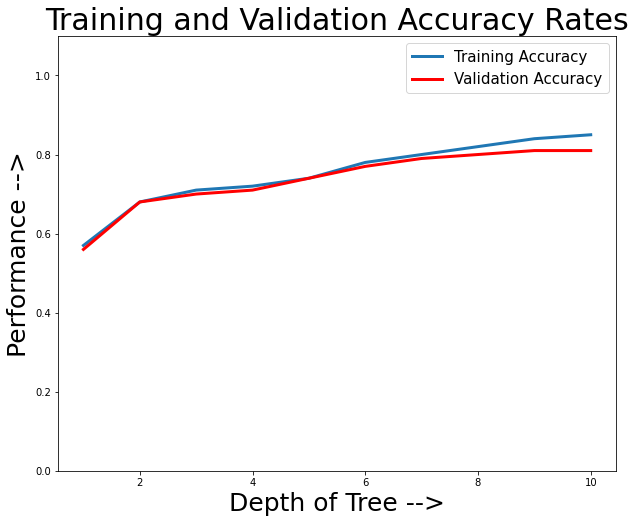

In [110]:
# Graphical representation of train and validation accuracy rates
plt.figure(figsize=(10, 8))
plt.plot(max_depth, train_acc1, label='Training Accuracy',linewidth=3)
plt.plot(max_depth, val_acc1, c='r',label='Validation Accuracy',linewidth=3)
plt.title('Training and Validation Accuracy Rates', fontsize=30)
plt.xlabel('Depth of Tree -->', fontsize=25)
plt.ylabel('Performance -->', fontsize=25)
plt.ylim(0,1.1)
plt.legend(loc='upper right',fontsize=15)
plt.show()

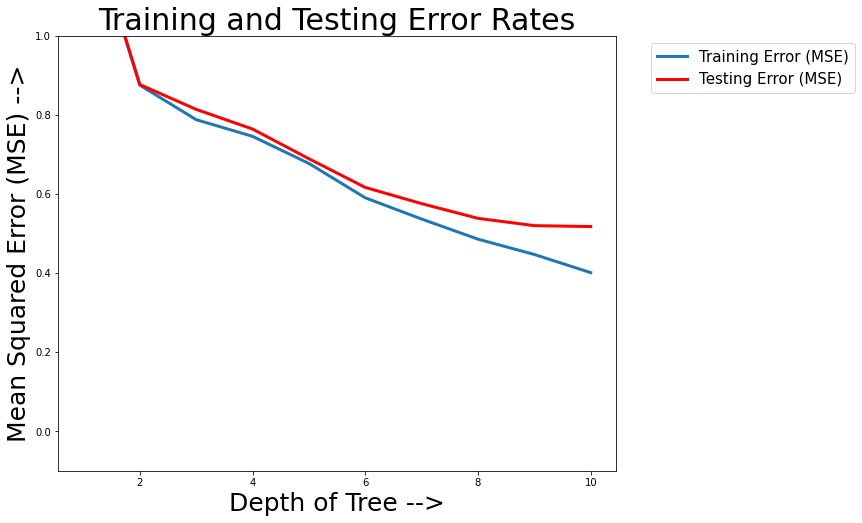

In [112]:
# Graphical representation of train and test error rates
plt.figure(figsize=(10,8))
plt.plot(max_depth,MSE_Train,label='Training Error (MSE)',linewidth=3)
plt.plot(max_depth,MSE_Test, c='r',label='Testing Error (MSE)',linewidth=3)
plt.title('Training and Testing Error Rates', fontsize=30)
plt.xlabel('Depth of Tree -->', fontsize=25)
plt.ylabel('Mean Squared Error (MSE) -->', fontsize=25)
plt.ylim(-0.1,1.0)
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left',fontsize=15)
plt.show()

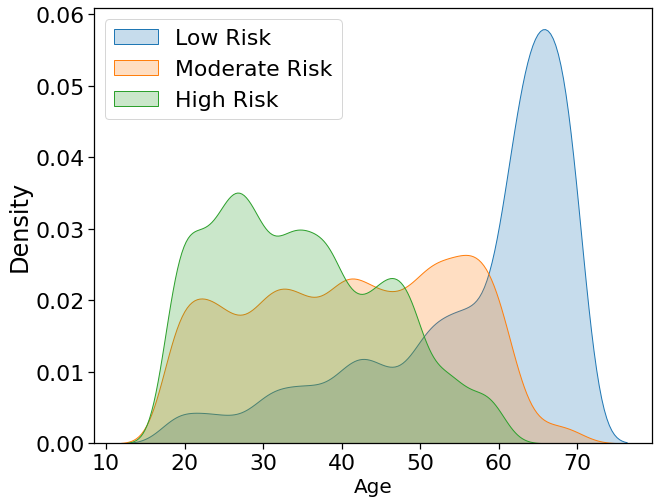

In [140]:
# Density Plot of Age for Surviving and Deceased Population
plt.figure(figsize=(10,8))

sns.kdeplot(risk_df["age"][res.risk_profile == 0], shade=True)
sns.kdeplot(risk_df["age"][res.risk_profile == 1], shade=True)
sns.kdeplot(risk_df["age"][res.risk_profile == 2], shade=True)

plt.legend(['Low Risk', 'Moderate Risk', 'High Risk'], loc='upper left')
#plt.title('Density Plot of Age for Surviving and Deceased Population')
plt.xlabel("Age",fontsize=20)
sns.set_context('notebook', font_scale = 2)
plt.show()

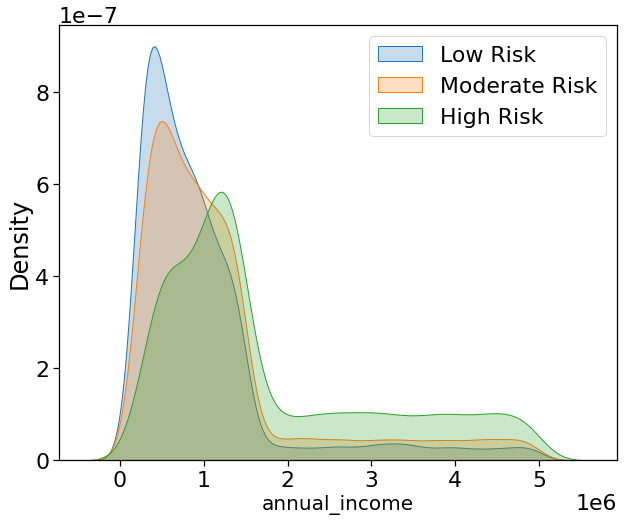

In [141]:
# Density Plot of Age for Surviving and Deceased Population
plt.figure(figsize=(10,8))

sns.kdeplot(risk_df["annual_income"][res.risk_profile == 0], shade=True)
sns.kdeplot(risk_df["annual_income"][res.risk_profile == 1], shade=True)
sns.kdeplot(risk_df["annual_income"][res.risk_profile == 2], shade=True)

plt.legend(['Low Risk', 'Moderate Risk', 'High Risk'])
#plt.title('Density Plot of Age for Surviving and Deceased Population')
plt.xlabel("annual_income",fontsize=20)
sns.set_context('notebook', font_scale = 2)
plt.show()

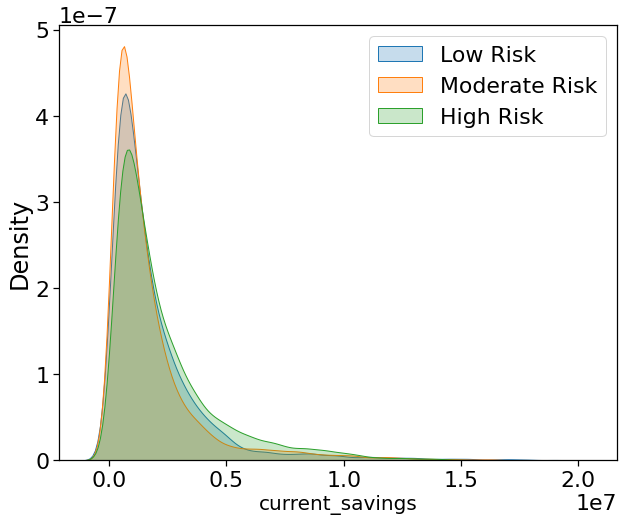

In [142]:
# Density Plot of Age for Surviving and Deceased Population
plt.figure(figsize=(10,8))

sns.kdeplot(risk_df["current_savings"][res.risk_profile == 0], shade=True)
sns.kdeplot(risk_df["current_savings"][res.risk_profile == 1], shade=True)
sns.kdeplot(risk_df["current_savings"][res.risk_profile == 2], shade=True)

plt.legend(['Low Risk', 'Moderate Risk', 'High Risk'])
#plt.title('Density Plot of Age for Surviving and Deceased Population')
plt.xlabel("current_savings",fontsize=20)
sns.set_context('notebook', font_scale = 2)
plt.show()

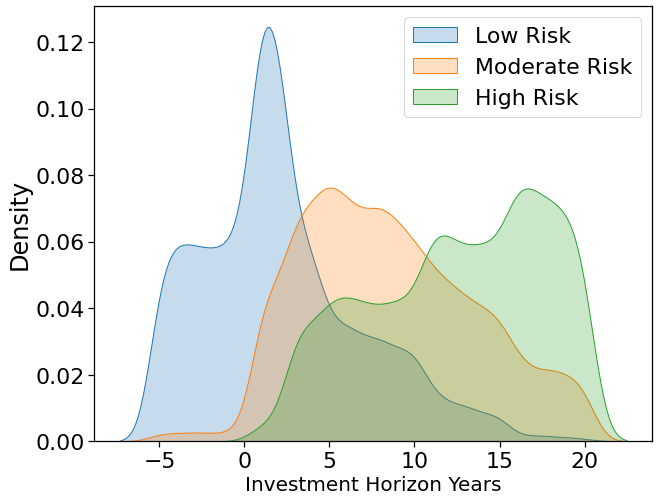

In [143]:
# Density Plot of Age for Surviving and Deceased Population
plt.figure(figsize=(10,8))

sns.kdeplot(risk_df["investment_horizon_years"][res.risk_profile == 0], shade=True)
sns.kdeplot(risk_df["investment_horizon_years"][res.risk_profile == 1], shade=True)
sns.kdeplot(risk_df["investment_horizon_years"][res.risk_profile == 2], shade=True)

plt.legend(['Low Risk', 'Moderate Risk', 'High Risk'])
#plt.title('Density Plot of Age for Surviving and Deceased Population')
plt.xlabel("Investment Horizon Years",fontsize=20)
sns.set_context('notebook', font_scale = 2)
plt.show()

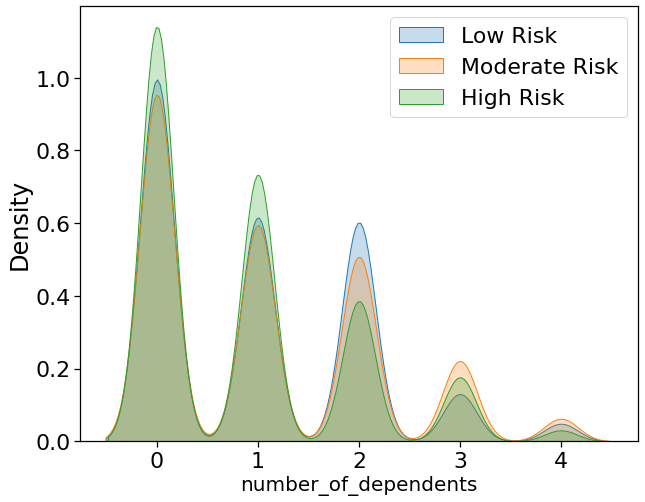

In [144]:
# Density Plot of Age for Surviving and Deceased Population
plt.figure(figsize=(10,8))

sns.kdeplot(risk_df["number_of_dependents"][res.risk_profile == 0], shade=True)
sns.kdeplot(risk_df["number_of_dependents"][res.risk_profile == 1], shade=True)
sns.kdeplot(risk_df["number_of_dependents"][res.risk_profile == 2], shade=True)

plt.legend(['Low Risk', 'Moderate Risk', 'High Risk'])
#plt.title('Density Plot of Age for Surviving and Deceased Population')
plt.xlabel("number_of_dependents",fontsize=20)
sns.set_context('notebook', font_scale = 2)
plt.show()

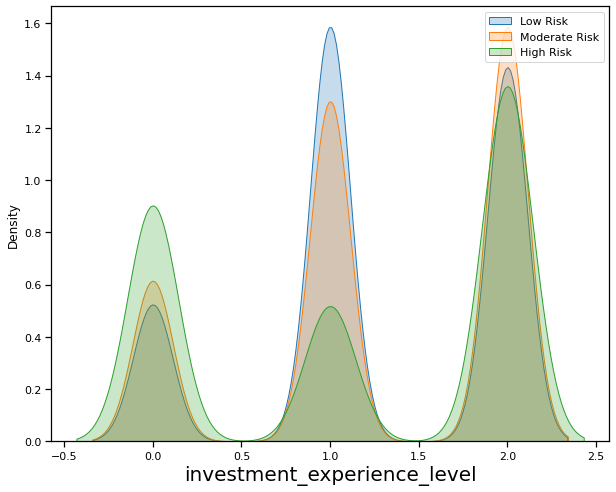

In [147]:
# Density Plot of Age for Surviving and Deceased Population
plt.figure(figsize=(10,8))

sns.kdeplot(risk_df["investment_experience_level"][res.risk_profile == 0], shade=True)
sns.kdeplot(risk_df["investment_experience_level"][res.risk_profile == 1], shade=True)
sns.kdeplot(risk_df["investment_experience_level"][res.risk_profile == 2], shade=True)

plt.legend(['Low Risk', 'Moderate Risk', 'High Risk'])
#plt.title('Density Plot of Age for Surviving and Deceased Population')
plt.xlabel("investment_experience_level",fontsize=20)
sns.set_context('notebook', font_scale = 1)
plt.show()

In [207]:
# Importing the train dataset
goal_df=pd.read_csv("data/goal_success_training_dataset.csv") 
goal_df['investment_experience_level']

0            Beginner
1            Advanced
2        Intermediate
3        Intermediate
4        Intermediate
             ...     
29995    Intermediate
29996        Beginner
29997        Beginner
29998    Intermediate
29999    Intermediate
Name: investment_experience_level, Length: 30000, dtype: object

In [210]:
# Making target column to numeric "acc, good, vgood = 1" and "unacc = 0"
ds4.goal_success = ds3["goal_success"].astype(str).replace('Unlikely', 0)
ds4.goal_success = ds3["goal_success"].astype(str).replace('Likely', 1)
ds4.goal_success = ds3["goal_success"].astype(str).replace('Moderate', 2)
# ds4

res1=ds4.astype(int)
res1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   goal_success  30000 non-null  int32
dtypes: int32(1)
memory usage: 117.3 KB


In [212]:
ds8=pd.DataFrame()
ds8['investment_experience_level']=goal_df.investment_experience_level
ds8.head(15)

,investment_experience_level
0,Beginner
1,Advanced
2,Intermediate
3,Intermediate
4,Intermediate
5,Advanced
6,Advanced
7,Beginner
8,Intermediate
9,Beginner


In [213]:
ds11=pd.DataFrame()
ds11=ds8
ds11

,investment_experience_level
0,Beginner
1,Advanced
2,Intermediate
3,Intermediate
4,Intermediate
...,...
29995,Intermediate
29996,Beginner
29997,Beginner
29998,Intermediate


In [215]:
# Making target column to numeric "acc, good, vgood = 1" and "unacc = 0"


ds8.investment_experience_level = ds11["investment_experience_level"].astype(str).replace('Beginner', 0)
ds8.investment_experience_level = ds11["investment_experience_level"].astype(str).replace('Intermediate', 1)
ds8.investment_experience_level = ds11["investment_experience_level"].astype(str).replace('Advanced', 2)
# ds8

res2=ds8.astype(int)
res2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 1 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   investment_experience_level  30000 non-null  int32
dtypes: int32(1)
memory usage: 117.3 KB


In [240]:
ds5=res2.sort_values(by='investment_experience_level')
ds5

,investment_experience_level
0,0
15094,0
15095,0
15096,0
15101,0
...,...
13114,2
23014,2
23013,2
13122,2


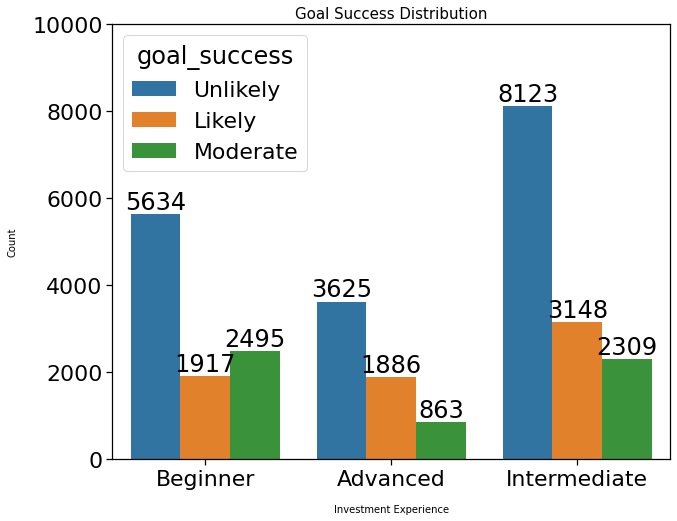

In [246]:
# Target
plt.figure(figsize=(10,8))

ax1=sns.countplot(x=goal_df["investment_experience_level"], hue =goal_df["goal_success"], )
#                   order=ds5['investment_experience_level'] )

abs_values1 = goal_df["goal_success"].value_counts(ascending=False)
rel_values1 = goal_df["goal_success"].value_counts(ascending=False, normalize=True).values * 100
lbls1 = [f'{p[0]} \n({round(p[1],2)}%)\n' for p in zip(abs_values1, rel_values1)]

# ax1.bar_label(container=ax1.containers[0], labels=lbls1)
# ax1.bar_label(container=ax1.containers[1], labels=lbls1)
# ax1.bar_label(container=ax1.containers[2], labels=lbls1)

for container in ax1.containers:
    ax1.bar_label(container)

# plt.legend(labels=['Low', 'Moderate', 'High'], loc="upper right")
plt.title('Goal Success Distribution', fontsize=15)
plt.xlabel('Investment Experience', fontsize=10, labelpad= 15)
plt.ylabel('Count', fontsize=10, labelpad= 15)
plt.ylim(0,10000)
plt.show()

In [149]:
# Checking if there is any null value in any column of the train dataset
goal_df.isnull().sum()

age                            0
annual_income                  0
current_savings                0
target_goal_amount             0
investment_horizon_years       0
number_of_dependents           0
investment_experience_level    0
goal_success                   0
dtype: int64

In [150]:
#  Non-Null count and data type info for each column of the train dataset
goal_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   age                          30000 non-null  int64 
 1   annual_income                30000 non-null  int64 
 2   current_savings              30000 non-null  int64 
 3   target_goal_amount           30000 non-null  int64 
 4   investment_horizon_years     30000 non-null  int64 
 5   number_of_dependents         30000 non-null  int64 
 6   investment_experience_level  30000 non-null  object
 7   goal_success                 30000 non-null  object
dtypes: int64(6), object(2)
memory usage: 1.8+ MB


In [157]:
ds4=pd.DataFrame()
ds4['goal_success']=goal_df.goal_success
ds4.head(15)

,goal_success
0,Unlikely
1,Unlikely
2,Unlikely
3,Unlikely
4,Unlikely
5,Unlikely
6,Likely
7,Unlikely
8,Unlikely
9,Likely


In [158]:
# Making target column to numeric "acc, good, vgood = 1" and "unacc = 0"
ds4.goal_success = ds3["goal_success"].astype(str).replace('Unlikely', 0)
ds4.goal_success = ds3["goal_success"].astype(str).replace('Likely', 1)
ds4.goal_success = ds3["goal_success"].astype(str).replace('Moderate', 2)
# ds4

res1=ds4.astype(int)
res1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   goal_success  30000 non-null  int32
dtypes: int32(1)
memory usage: 117.3 KB


In [161]:
ds5=res1.sort_values(by='goal_success')
# ds5

In [164]:
df=pd.DataFrame()
df['Goal Success']=goal_df.goal_success
# df

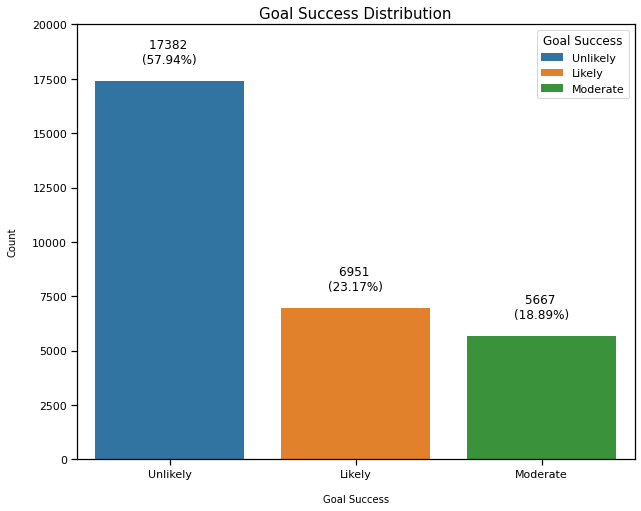

In [167]:
# Target
plt.figure(figsize=(10,8))

ax1=sns.countplot(x=goal_df["goal_success"], hue =df['Goal Success'] , dodge=False, 
              order=goal_df['goal_success'].value_counts(ascending=False).index)

abs_values1 = goal_df['goal_success'].value_counts(ascending=False)
rel_values1 = goal_df['goal_success'].value_counts(ascending=False, normalize=True).values * 100
lbls1 = [f'{p[0]} \n({round(p[1],2)}%)\n' for p in zip(abs_values1, rel_values1)]

ax1.bar_label(container=ax1.containers[0], labels=lbls1)
ax1.bar_label(container=ax1.containers[1], labels=lbls1)
ax1.bar_label(container=ax1.containers[2], labels=lbls1)

# plt.legend(labels=['Low', 'Moderate', 'High'], loc="upper right")
plt.title('Goal Success Distribution', fontsize=15)
plt.xlabel('Goal Success', fontsize=10, labelpad= 15)
plt.ylabel('Count', fontsize=10, labelpad= 15)
plt.ylim(0,20000)
plt.show()

In [173]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Decision Tree Classifier (using criterion : Gini )
train_acc2=[]
val_acc2=[]
test_acc2=[]
max_depth=[]
# Calculating the test error
MSE_Train1=[]
MSE_Test1=[]

for i in range(1,16):
    
    goal_df=pd.read_csv("data/goal_success_training_dataset.csv") 

    target_col="goal_success"

    label_encoder = LabelEncoder()
    goal_df["investment_experience_level"]=label_encoder.fit_transform(goal_df["investment_experience_level"])
    feature_cols=["age","annual_income","current_savings","target_goal_amount","investment_horizon_years","number_of_dependents","investment_experience_level"]

    X=goal_df[feature_cols]
    y=goal_df[target_col]

    y_label_encoder = LabelEncoder()
    y_encoded = y_label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.3, random_state=42)
   
        

    # ******************************************    
        
    max_depth.append(i)
    
    # Random Forest Classifier
    random_forest_2 = RandomForestClassifier(criterion='entropy', random_state=42, n_jobs=-1, max_depth=i, n_estimators=300, oob_score=True)
    
    
    # Train the model on the training data
    random_forest_2.fit(X_train,y_train)
#     y_pred_1 = model.predict(X_train)
    
    # Make predictions on the given data
    y_pred_train = random_forest_2.predict(X_train)
    y_pred_test = random_forest_2.predict(X_test)
    
    train_acc2.append(round(random_forest_2.score(X_train, y_train),2))
    val_acc2.append(round(random_forest_2.score(X_test, y_test),2))

    # Evaluating accuracy, precision, recall and f1-score
    accuracy_decision_tree1 = accuracy_score(y_test, y_pred_test)
    precision_decision_tree1 = precision_score(y_test, y_pred_test, average='weighted')
    recall_decision_tree1 = recall_score(y_test, y_pred_test, average='weighted')
    f1_decision_tree1 = f1_score(y_test, y_pred_test, average='weighted')
    
    test_acc2.append(round(accuracy_decision_tree1,2))
    
    # Calculating mean square error
    mse_train1 = np.sqrt(mean_squared_error(y_train, y_pred_train))
    mse_test1 = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    MSE_Train1.append(mse_train1)
    MSE_Test1.append(mse_test1)

    print ('Max_Depth:', i)
    print(f'Decision Tree Accuracy: {accuracy_decision_tree1:.2f}')
    print(f'Decision Tree Precision: {precision_decision_tree1:.2f}')
    print(f'Decision Tree Recall: {recall_decision_tree1:.2f}')
    print(f'Decision Tree F1 Score: {f1_decision_tree1:.2f}')
    print('--------------------------------------------------------')
    print ('Mean Squared Error (TRAIN):', mse_train1)
    print ('Mean Squared Error (TEST):', mse_test1)
    print('\n')

    

C:\Users\USER\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Max_Depth: 1
Decision Tree Accuracy: 0.58
Decision Tree Precision: 0.33
Decision Tree Recall: 0.58
Decision Tree F1 Score: 0.42
--------------------------------------------------------
Mean Squared Error (TRAIN): 1.0530906893520615
Mean Squared Error (TEST): 1.0636415436289302




C:\Users\USER\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Max_Depth: 2
Decision Tree Accuracy: 0.75
Decision Tree Precision: 0.63
Decision Tree Recall: 0.75
Decision Tree F1 Score: 0.68
--------------------------------------------------------
Mean Squared Error (TRAIN): 0.6899620417440506
Mean Squared Error (TEST): 0.6737952211169207


Max_Depth: 3
Decision Tree Accuracy: 0.75
Decision Tree Precision: 0.62
Decision Tree Recall: 0.75
Decision Tree F1 Score: 0.68
--------------------------------------------------------
Mean Squared Error (TRAIN): 0.6854612628421412
Mean Squared Error (TEST): 0.6702404212088542


Max_Depth: 4
Decision Tree Accuracy: 0.76
Decision Tree Precision: 0.72
Decision Tree Recall: 0.76
Decision Tree F1 Score: 0.71
--------------------------------------------------------
Mean Squared Error (TRAIN): 0.6348978170503015
Mean Squared Error (TEST): 0.6252999280345393


Max_Depth: 5
Decision Tree Accuracy: 0.78
Decision Tree Precision: 0.74
Decision Tree Recall: 0.78
Decision Tree F1 Score: 0.73
--------------------------------

In [174]:
train_acc2

[0.58,
 0.74,
 0.74,
 0.76,
 0.77,
 0.79,
 0.81,
 0.84,
 0.87,
 0.9,
 0.93,
 0.96,
 0.98,
 0.99,
 1.0]

In [175]:
val_acc2

[0.58,
 0.75,
 0.75,
 0.76,
 0.78,
 0.79,
 0.81,
 0.82,
 0.84,
 0.85,
 0.86,
 0.86,
 0.87,
 0.87,
 0.87]

In [176]:
test_acc2

[0.58,
 0.75,
 0.75,
 0.76,
 0.78,
 0.79,
 0.81,
 0.82,
 0.84,
 0.85,
 0.86,
 0.86,
 0.87,
 0.87,
 0.87]

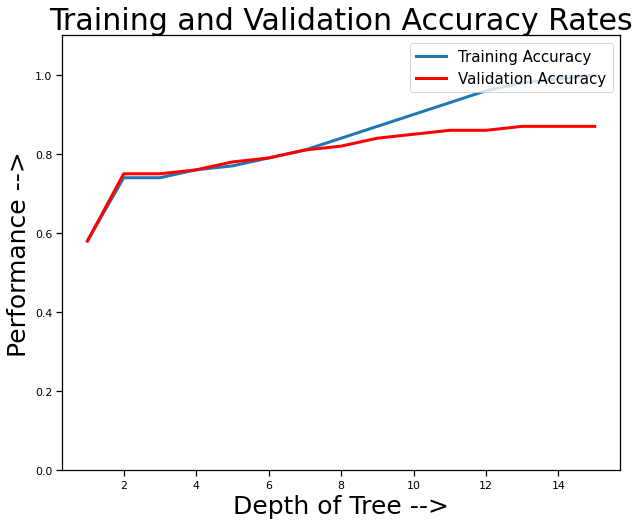

In [177]:
# Graphical representation of train and validation accuracy rates
plt.figure(figsize=(10, 8))
plt.plot(max_depth, train_acc2, label='Training Accuracy',linewidth=3)
plt.plot(max_depth, val_acc2, c='r',label='Validation Accuracy',linewidth=3)
plt.title('Training and Validation Accuracy Rates', fontsize=30)
plt.xlabel('Depth of Tree -->', fontsize=25)
plt.ylabel('Performance -->', fontsize=25)
plt.ylim(0,1.1)
plt.legend(loc='upper right',fontsize=15)
plt.show()

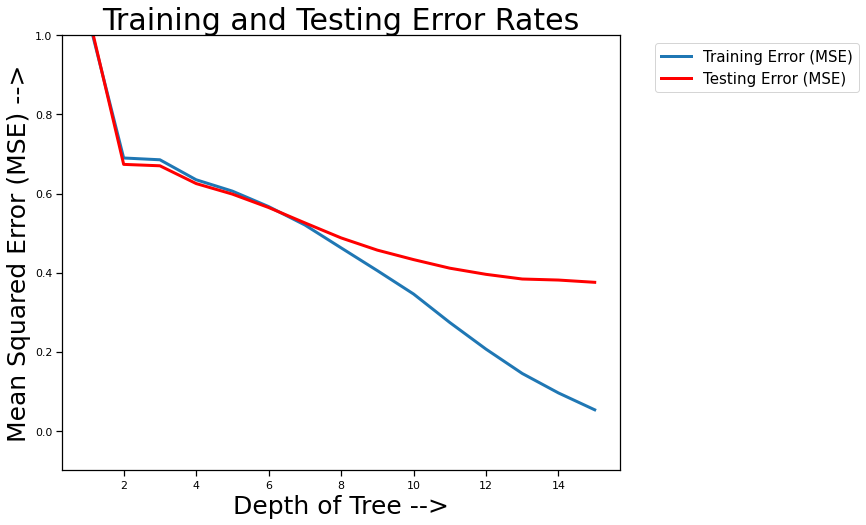

In [178]:
# Graphical representation of train and test error rates
plt.figure(figsize=(10,8))
plt.plot(max_depth,MSE_Train1,label='Training Error (MSE)',linewidth=3)
plt.plot(max_depth,MSE_Test1, c='r',label='Testing Error (MSE)',linewidth=3)
plt.title('Training and Testing Error Rates', fontsize=30)
plt.xlabel('Depth of Tree -->', fontsize=25)
plt.ylabel('Mean Squared Error (MSE) -->', fontsize=25)
plt.ylim(-0.1,1.0)
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left',fontsize=15)
plt.show()

In [179]:
goal_df.columns

Index(['age', 'annual_income', 'current_savings', 'target_goal_amount',
       'investment_horizon_years', 'number_of_dependents',
       'investment_experience_level', 'goal_success'],
      dtype='object')

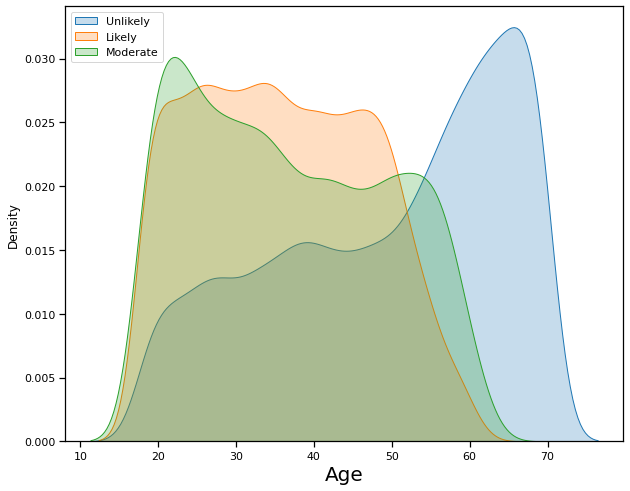

In [180]:
# Density Plot of Age for Surviving and Deceased Population
plt.figure(figsize=(10,8))

sns.kdeplot(goal_df["age"][res1.goal_success == 0], shade=True)
sns.kdeplot(goal_df["age"][res1.goal_success == 1], shade=True)
sns.kdeplot(goal_df["age"][res1.goal_success == 2], shade=True)

plt.legend(['Unlikely', 'Likely', 'Moderate'], loc='upper left')
#plt.title('Density Plot of Age for Surviving and Deceased Population')
plt.xlabel("Age",fontsize=20)
sns.set_context('notebook', font_scale = 2)
plt.show()

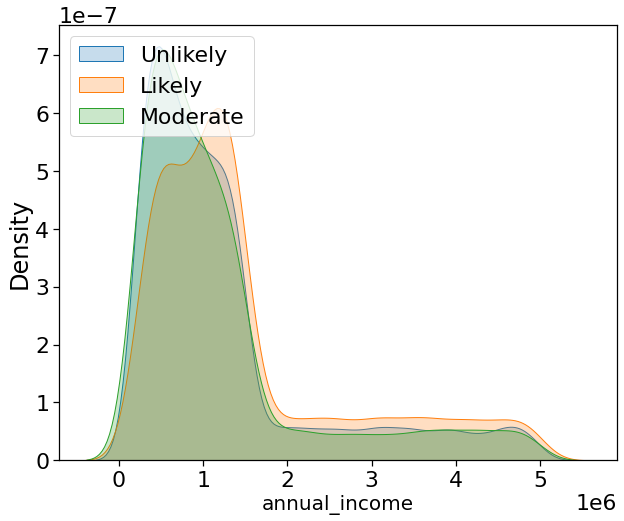

In [181]:
# Density Plot of Age for Surviving and Deceased Population
plt.figure(figsize=(10,8))

sns.kdeplot(goal_df["annual_income"][res1.goal_success == 0], shade=True)
sns.kdeplot(goal_df["annual_income"][res1.goal_success == 1], shade=True)
sns.kdeplot(goal_df["annual_income"][res1.goal_success == 2], shade=True)

plt.legend(['Unlikely', 'Likely', 'Moderate'], loc='upper left')
#plt.title('Density Plot of Age for Surviving and Deceased Population')
plt.xlabel("annual_income",fontsize=20)
sns.set_context('notebook', font_scale = 2)
plt.show()

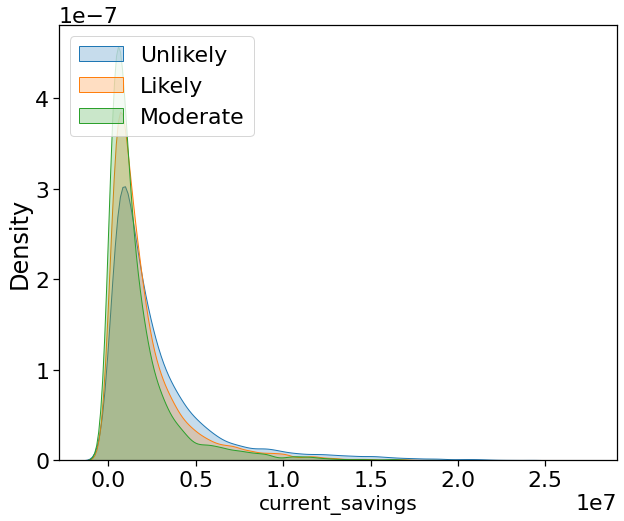

In [182]:
plt.figure(figsize=(10,8))

sns.kdeplot(goal_df["current_savings"][res1.goal_success == 0], shade=True)
sns.kdeplot(goal_df["current_savings"][res1.goal_success == 1], shade=True)
sns.kdeplot(goal_df["current_savings"][res1.goal_success == 2], shade=True)

plt.legend(['Unlikely', 'Likely', 'Moderate'], loc='upper left')
#plt.title('Density Plot of Age for Surviving and Deceased Population')
plt.xlabel("current_savings",fontsize=20)
sns.set_context('notebook', font_scale = 2)
plt.show()

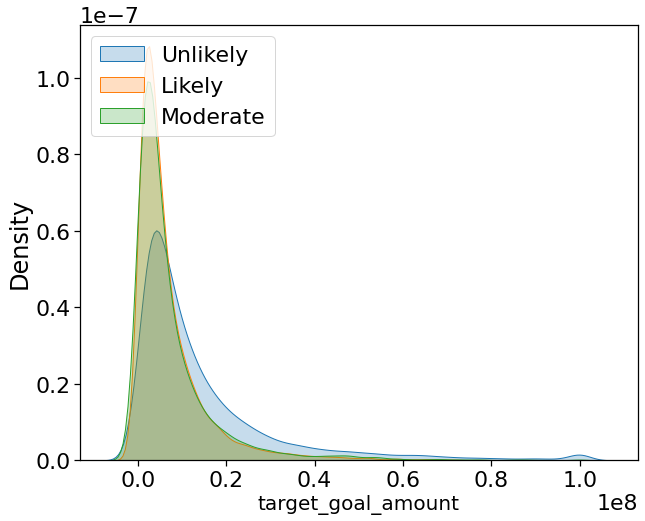

In [183]:
plt.figure(figsize=(10,8))

sns.kdeplot(goal_df["target_goal_amount"][res1.goal_success == 0], shade=True)
sns.kdeplot(goal_df["target_goal_amount"][res1.goal_success == 1], shade=True)
sns.kdeplot(goal_df["target_goal_amount"][res1.goal_success == 2], shade=True)

plt.legend(['Unlikely', 'Likely', 'Moderate'], loc='upper left')
#plt.title('Density Plot of Age for Surviving and Deceased Population')
plt.xlabel("target_goal_amount",fontsize=20)
sns.set_context('notebook', font_scale = 2)
plt.show()

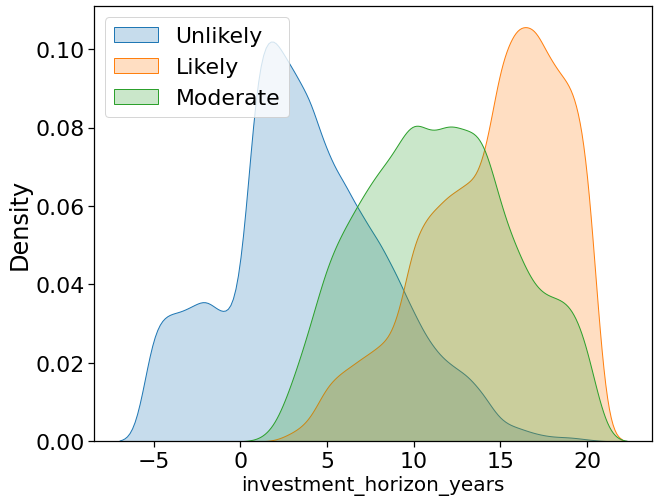

In [184]:
plt.figure(figsize=(10,8))

sns.kdeplot(goal_df["investment_horizon_years"][res1.goal_success == 0], shade=True)
sns.kdeplot(goal_df["investment_horizon_years"][res1.goal_success == 1], shade=True)
sns.kdeplot(goal_df["investment_horizon_years"][res1.goal_success == 2], shade=True)

plt.legend(['Unlikely', 'Likely', 'Moderate'], loc='upper left')
#plt.title('Density Plot of Age for Surviving and Deceased Population')
plt.xlabel("investment_horizon_years",fontsize=20)
sns.set_context('notebook', font_scale = 2)
plt.show()

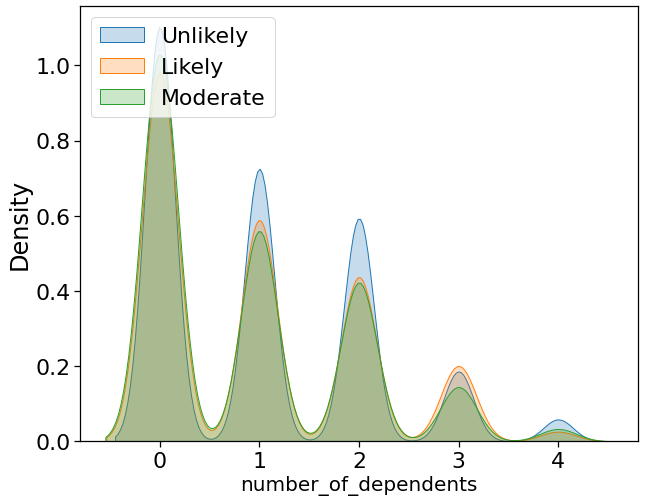

In [185]:
plt.figure(figsize=(10,8))

sns.kdeplot(goal_df["number_of_dependents"][res1.goal_success == 0], shade=True)
sns.kdeplot(goal_df["number_of_dependents"][res1.goal_success == 1], shade=True)
sns.kdeplot(goal_df["number_of_dependents"][res1.goal_success == 2], shade=True)

plt.legend(['Unlikely', 'Likely', 'Moderate'], loc='upper left')
#plt.title('Density Plot of Age for Surviving and Deceased Population')
plt.xlabel("number_of_dependents",fontsize=20)
sns.set_context('notebook', font_scale = 2)
plt.show()

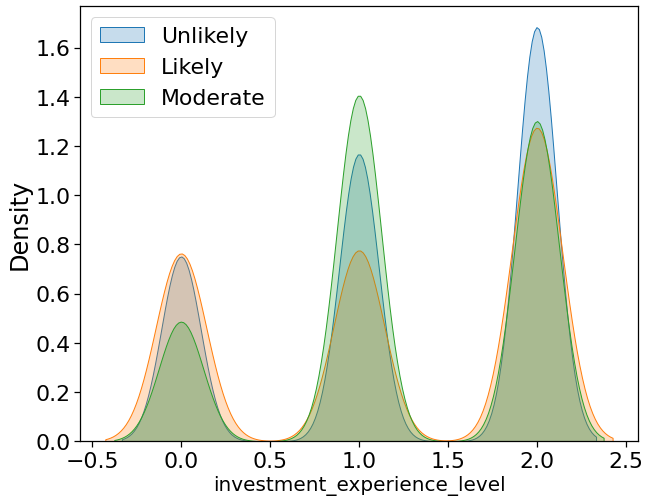

In [186]:
plt.figure(figsize=(10,8))

sns.kdeplot(goal_df["investment_experience_level"][res1.goal_success == 0], shade=True)
sns.kdeplot(goal_df["investment_experience_level"][res1.goal_success == 1], shade=True)
sns.kdeplot(goal_df["investment_experience_level"][res1.goal_success == 2], shade=True)

plt.legend(['Unlikely', 'Likely', 'Moderate'], loc='upper left')
#plt.title('Density Plot of Age for Surviving and Deceased Population')
plt.xlabel("investment_experience_level",fontsize=20)
sns.set_context('notebook', font_scale = 2)
plt.show()